# Time Series Forecasting with Prophet

```{index} Time series analysis ; Prophet
```

Predicting future trends is a common application in time series analysis. In this experiment, we will use [Meta's Prophet](https://facebook.github.io/prophet/) library to predict future trends for births in Malaysia, based on available public data. Prophet is a forecasting tool developed by Meta that is available in Python and R. It is designed for analyzing time series data with daily observations that display patterns on different time scales.

Prophet is particularly useful because it handles missing data, shifts in the trend, and large outliers in a robust manner. Additionally, it provides a straightforward way to include the effects of holidays and seasonality in the forecast. The model decomposes time series data into trend, seasonality, and holiday effects, making it easy to understand the impact of these components on the forecast.

In this experiment, we will incorporate additional regressors, such as temperature and pollutant levels, to see how these factors influence birth rates. This approach allows us to account for external variables that might affect the trend and seasonality of births.

## Load the datasets

In this experiment we will use a couple of public Kaggle datasets, one containing weather data for Malaysia, and the other containing the number of births.

In [1]:
# Download https://www.kaggle.com/datasets/shahmirvarqha/weather-data-malaysia?select=full-weather.csv using the Kaggle API

!kaggle datasets download -d shahmirvarqha/weather-data-malaysia -f full-weather.csv -p .data/
!rm -f .data/full-weather.csv
!unzip .data/full-weather.csv.zip -d .data/
!rm .data/full-weather.csv.zip

Dataset URL: https://www.kaggle.com/datasets/shahmirvarqha/weather-data-malaysia
License(s): Attribution 4.0 International (CC BY 4.0)
100%|████████████████████████████████████████| 305M/305M [00:37<00:00, 8.24MB/s]
100%|████████████████████████████████████████| 305M/305M [00:37<00:00, 8.61MB/s]
Archive:  .data/full-weather.csv.zip
  inflating: .data/full-weather.csv  


In [2]:
# Download https://www.kaggle.com/datasets/jylim21/malaysia-public-data

!kaggle datasets download -d jylim21/malaysia-public-data -p .data/ --unzip

Dataset URL: https://www.kaggle.com/datasets/jylim21/malaysia-public-data
License(s): Community Data License Agreement - Permissive - Version 1.0
100%|█████████████████████████████████████████| 156k/156k [00:00<00:00, 633kB/s]
100%|█████████████████████████████████████████| 156k/156k [00:00<00:00, 633kB/s]


In [3]:
# Disable all warnings
import warnings
warnings.filterwarnings('ignore')

Let's load these as dataframes and inspect the first few rows of each dataset.

In [4]:
# Load full-weather.csv and births.csv
import pandas as pd

weather = pd.read_csv('.data/full-weather.csv')
births = pd.read_csv('.data/births.csv')

## Preprocessing the data

We will need to adjust the available data to fit our purposes, including filling in gaps and merging the datasets.

In [5]:
# Display the first 5 rows of each dataframe
weather.head().style.background_gradient(cmap='Greens')

,datetime,place,city,state,temperature,pressure,dew_point,humidity,wind_speed,gust,wind_chill,uv_index,feels_like_temperature,visibility,solar_radiation,pollutant_value,precipitation_rate,precipitation_total
0,2023-03-21 09:00:00,Yan,Yan,Kedah,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,55.000000,nan,nan
1,2023-04-11 19:00:00,Yan,Yan,Kedah,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,64.000000,nan,nan
2,2023-03-22 17:00:00,Yan,Yan,Kedah,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,60.000000,nan,nan
3,2023-04-06 01:00:00,Yan,Yan,Kedah,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,56.000000,nan,nan
4,2023-03-29 14:00:00,Yan,Yan,Kedah,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,43.000000,nan,nan


In [6]:
births.head().style.background_gradient(cmap='Greens')

,date,state,births
0,1920-01-01,Malaysia,96
1,1920-01-02,Malaysia,115
2,1920-01-03,Malaysia,111
3,1920-01-04,Malaysia,101
4,1920-01-05,Malaysia,95


The `datetime` column is a string, which we want to convert to a Pandas datetime object.

In [7]:
# Convert the 'date' column in both dataframes to datetime
weather['datetime'] = pd.to_datetime(weather['datetime'])
births['date'] = pd.to_datetime(births['date'])

You will also notice that the weather dataset contains multiple measurements in a single day, which we will need to aggregate to daily values. Also, different measurements are available for different locations in Malaysia - we will average these to get a single value for the whole country, as births are recorded at the national level.

In [8]:
# Average all features in the weather dataframe by day

weather['date'] = weather['datetime'].dt.date
births['date'] = births['date'].dt.date

# Drop the columns 'place', 'city', 'state', and 'datetime'
weather.drop(columns=['place', 'city', 'state', 'datetime'], inplace=True)

# Group by date and calculate the mean
daily_average = weather.groupby('date').mean().reset_index()

# Replace the original DataFrame with the new one
weather = daily_average

Let's check what each column of the weather dataset now looks like, and statistics for each column.

In [9]:
weather.describe().drop('count').style.background_gradient(cmap='Greens')

,temperature,pressure,dew_point,humidity,wind_speed,gust,wind_chill,uv_index,feels_like_temperature,visibility,solar_radiation,pollutant_value,precipitation_rate,precipitation_total
mean,27.525318,1008.064436,23.802035,81.285628,6.477225,27.091990,27.451315,0.668326,30.454487,8.581339,145.644984,42.702836,5.485694,11.973146
std,0.880795,2.010772,1.131944,5.905757,2.322445,19.631542,0.822243,0.891573,1.489563,0.463320,38.743467,10.982237,83.984910,112.717724
min,23.444444,997.887076,13.897368,15.484936,1.163329,0.220339,23.361953,0.000000,23.777778,2.786753,0.000000,15.125438,0.000000,0.000000
25%,26.927912,1006.906494,23.562020,79.549704,5.962533,3.451059,26.900298,0.000000,29.428260,8.538110,123.076436,36.583132,0.025851,0.323896
50%,27.442563,1007.998112,23.987941,82.537236,6.951197,34.000000,27.387931,0.000000,30.331387,8.682292,148.400014,41.642413,0.208065,1.937684
75%,28.044096,1009.271202,24.382787,84.729012,7.759133,40.666667,27.943433,1.632655,31.408997,8.787016,170.261246,47.933751,0.548623,5.383185
max,33.000000,1016.209393,26.255048,95.250709,38.743243,593.000000,33.000000,2.972896,40.000000,9.000000,419.813559,136.627451,2539.750000,2539.750000


We have two separate datasets, one for weather and one for births. We will merge these datasets on the date column.

In [10]:
# Merge the two dataframes on the 'date' column, where the date is a datetime64 type
data = pd.merge(births, weather, on='date')
data.drop(columns=['state'], inplace=True)

In [11]:
data.head().style.background_gradient(cmap='Greens')

,date,births,temperature,pressure,dew_point,humidity,wind_speed,gust,wind_chill,uv_index,feels_like_temperature,visibility,solar_radiation,pollutant_value,precipitation_rate,precipitation_total
0,1996-08-09,1520,29.714286,1005.877143,24.000000,72.571429,5.857143,nan,29.714286,nan,33.571429,8.625000,nan,nan,nan,nan
1,1996-08-17,1539,25.407407,1007.800690,23.769231,90.615385,7.695652,nan,25.423077,0.000000,26.615385,8.096774,nan,nan,nan,nan
2,1996-08-18,1423,26.035714,1007.954800,23.464286,86.500000,6.775000,nan,25.700000,0.000000,27.660714,8.372881,nan,nan,nan,nan
3,1996-09-11,1756,25.709677,1005.271724,23.709677,88.967742,5.631579,nan,25.709677,0.000000,27.032258,8.612903,nan,nan,nan,nan
4,1996-09-12,1638,32.333333,1001.980000,23.833333,62.000000,9.833333,nan,32.333333,nan,37.833333,9.000000,nan,nan,nan,nan


Let's also fill in any missing values - we will use the mean value for each column to fill in the gaps. This is a simple approach, and in practice, you might want to use more sophisticated methods to fill in missing data, but for the purposes of this experiment, this will suffice.

In [12]:
# Fill in missing values for each numerical column with the mean of that column

mean_values = data.select_dtypes(include='number').mean()
data.fillna(mean_values, inplace=True)

In [13]:
data.head().style.background_gradient(cmap='Greens')

,date,births,temperature,pressure,dew_point,humidity,wind_speed,gust,wind_chill,uv_index,feels_like_temperature,visibility,solar_radiation,pollutant_value,precipitation_rate,precipitation_total
0,1996-08-09,1520,29.714286,1005.877143,24.000000,72.571429,5.857143,27.890241,29.714286,0.651795,33.571429,8.625000,145.609684,42.495870,5.762057,12.349303
1,1996-08-17,1539,25.407407,1007.800690,23.769231,90.615385,7.695652,27.890241,25.423077,0.000000,26.615385,8.096774,145.609684,42.495870,5.762057,12.349303
2,1996-08-18,1423,26.035714,1007.954800,23.464286,86.500000,6.775000,27.890241,25.700000,0.000000,27.660714,8.372881,145.609684,42.495870,5.762057,12.349303
3,1996-09-11,1756,25.709677,1005.271724,23.709677,88.967742,5.631579,27.890241,25.709677,0.000000,27.032258,8.612903,145.609684,42.495870,5.762057,12.349303
4,1996-09-12,1638,32.333333,1001.980000,23.833333,62.000000,9.833333,27.890241,32.333333,0.651795,37.833333,9.000000,145.609684,42.495870,5.762057,12.349303


In [14]:
data.describe().drop('count').style.background_gradient(cmap='Greens')

,births,temperature,pressure,dew_point,humidity,wind_speed,gust,wind_chill,uv_index,feels_like_temperature,visibility,solar_radiation,pollutant_value,precipitation_rate,precipitation_total
mean,1399.317195,27.527325,1007.996160,23.783828,81.213123,6.569408,27.890241,27.451720,0.651795,30.441393,8.582386,145.609684,42.495870,5.762057,12.349303
std,151.534289,0.879650,1.962270,1.131681,5.905187,2.211017,15.385685,0.804632,0.871842,1.454741,0.455176,20.630437,9.242458,53.834741,72.250576
min,697.000000,23.444444,997.887076,13.897368,15.484936,1.163329,0.220339,23.361953,0.000000,23.777778,2.786753,0.000000,15.125438,0.000000,0.000000
25%,1299.000000,26.930111,1006.886622,23.554108,79.513711,6.182207,27.890241,26.924528,0.000000,29.463124,8.549533,145.609684,38.520319,0.356371,3.218137
50%,1411.000000,27.449486,1007.970255,23.967937,82.460700,6.919526,27.890241,27.435050,0.000000,30.406473,8.672687,145.609684,42.495870,5.762057,12.349303
75%,1509.000000,28.041932,1009.161633,24.359104,84.654464,7.738506,37.000000,27.917808,1.611262,31.328596,8.783403,145.609684,44.772431,5.762057,12.349303
max,2200.000000,33.000000,1016.209393,26.255048,95.250709,38.743243,593.000000,33.000000,2.972896,40.000000,9.000000,419.813559,136.627451,2539.750000,2539.750000


Finally, let us save the merged dataset to a CSV file for future use.

In [15]:
# Save the final DataFrame to a CSV file
data.to_csv('.data/births_and_weather.csv', index=False)

## Visualising a few features

Let's visualise the data to get a better understanding of the trends and seasonality. We will focus on births, temperature, and pollutant levels.

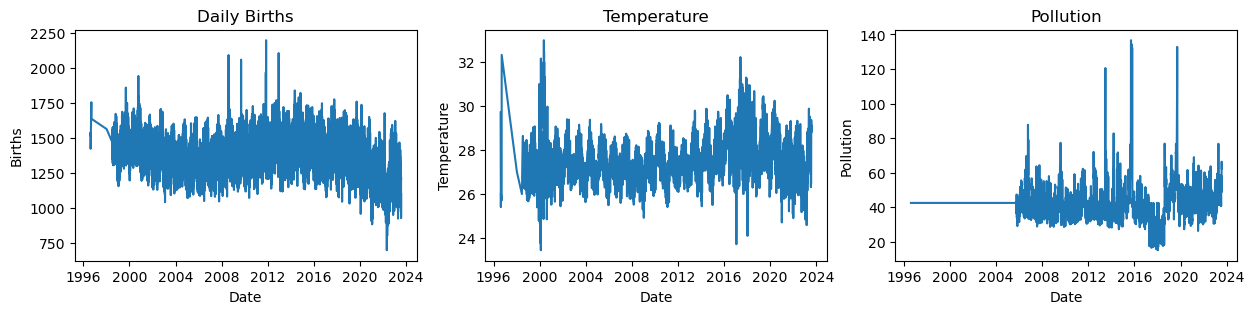

In [16]:
# Plot births, temperature and pollutant levels as a 1x3 grid

import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 3, figsize=(15, 3))

axs[0].plot(data['date'], data['births'])
axs[0].set_title('Daily Births')
axs[0].set_xlabel('Date')
axs[0].set_ylabel('Births')

axs[1].plot(data['date'], data['temperature'])
axs[1].set_title('Temperature')
axs[1].set_xlabel('Date')
axs[1].set_ylabel('Temperature')

axs[2].plot(data['date'], data['pollutant_value'])
axs[2].set_title('Pollution')
axs[2].set_xlabel('Date')
axs[2].set_ylabel('Pollution')

plt.show()

## Building the model

We are now ready to build a Prophet model. We will be forecasting five years into the future, and we will adjust Prophet's change point prior scale to make the model more flexible. First, we will forecast temperature and pollutant levels, and then we will forecast the number of births using these two features as regressors.

```{tip}
The change point prior scale parameter controls the flexibility of the model. A higher value makes the model more flexible, allowing it to capture more fluctuations in the data. However, this can lead to overfitting, so it is important to tune this parameter carefully.
```

Notice that Prophet requires the input data to have two columns: `ds` and `y`. The `ds` column contains the dates, and the `y` column contains the values we want to forecast.

In [17]:
from prophet import Prophet

future_period = 365*5
prior_scale = 0.05

# Prepare the data for Prophet
df_temperature = data[['date', 'temperature']].rename(columns={'date': 'ds', 'temperature': 'y'})
df_pollutant = data[['date', 'pollutant_value']].rename(columns={'date': 'ds', 'pollutant_value': 'y'})

# Initialize the Prophet model
model_temperature = Prophet(changepoint_prior_scale=prior_scale)
model_pollutant = Prophet(changepoint_prior_scale=prior_scale)

# Fit the model
model_temperature.fit(df_temperature)

# Make a dataframe to hold future predictions
future_temperature = model_temperature.make_future_dataframe(periods=future_period)
forecast_temperature = model_temperature.predict(future_temperature)

model_pollutant.fit(df_pollutant)
future_pollutant = model_pollutant.make_future_dataframe(periods=future_period)
forecast_pollutant = model_pollutant.predict(future_pollutant)

08:35:06 - cmdstanpy - INFO - Chain [1] start processing
08:35:07 - cmdstanpy - INFO - Chain [1] done processing
08:35:08 - cmdstanpy - INFO - Chain [1] start processing
08:35:09 - cmdstanpy - INFO - Chain [1] done processing


Prophet allows us to easily visuallise the forecasted values, as well as the uncertainty intervals. We will also include the change points in the forecast plot, which are the points where the trend changes direction.

```{tip}
Prophet uses a piecewise linear model to capture the trend in the data. The change points are the points where the trend changes direction, and they are automatically selected by the model. You can also manually specify the change points if you have domain knowledge about the data.
```

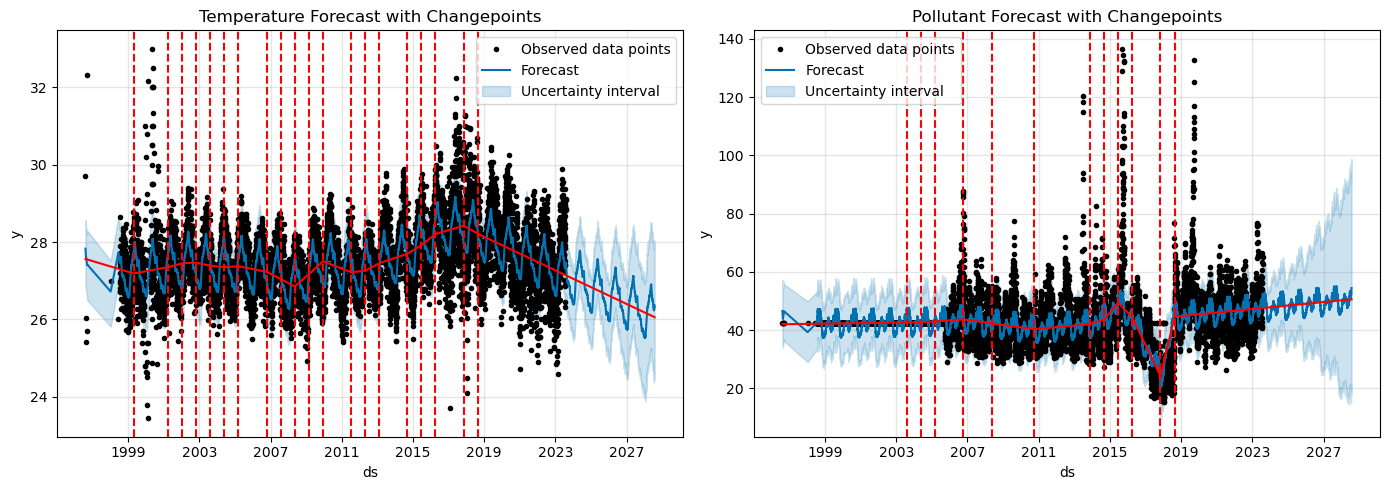

In [18]:
from prophet.plot import add_changepoints_to_plot
import matplotlib.pyplot as plt

# Create a figure with a 2-column, 1-row grid
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Plot the temperature forecast on the first subplot
fig1 = model_temperature.plot(forecast_temperature, ax=axs[0], include_legend=True)
axs[0].set_title('Temperature Forecast with Changepoints')
# Add changepoints to the plot
add_changepoints_to_plot(axs[0], model_temperature, forecast_temperature)

# Plot the pollutant forecast on the second subplot
fig2 = model_pollutant.plot(forecast_pollutant, ax=axs[1], include_legend=True)
axs[1].set_title('Pollutant Forecast with Changepoints')
# Add changepoints to the plot
add_changepoints_to_plot(axs[1], model_pollutant, forecast_pollutant)

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

We can also plot the components of the forecast, including the trend, seasonality, and holidays. This allows us to understand how these components contribute to the forecast. Notice how in the yearly seasonality plot, the model captures the peaks in temperature and pollutant levels during certain months.

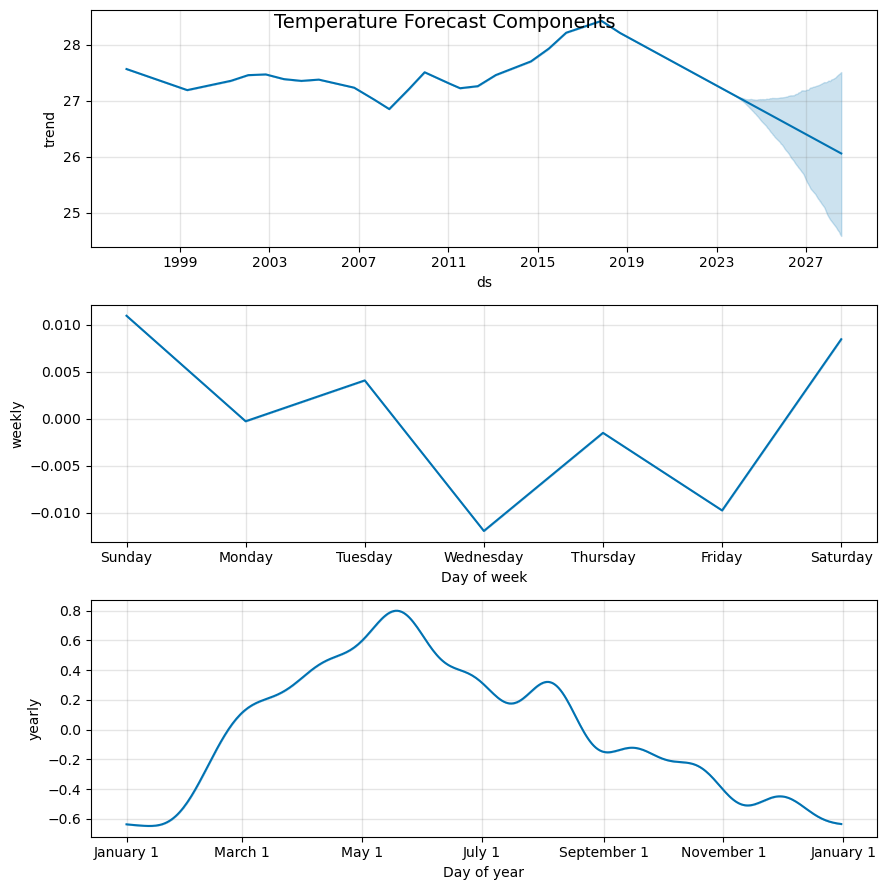

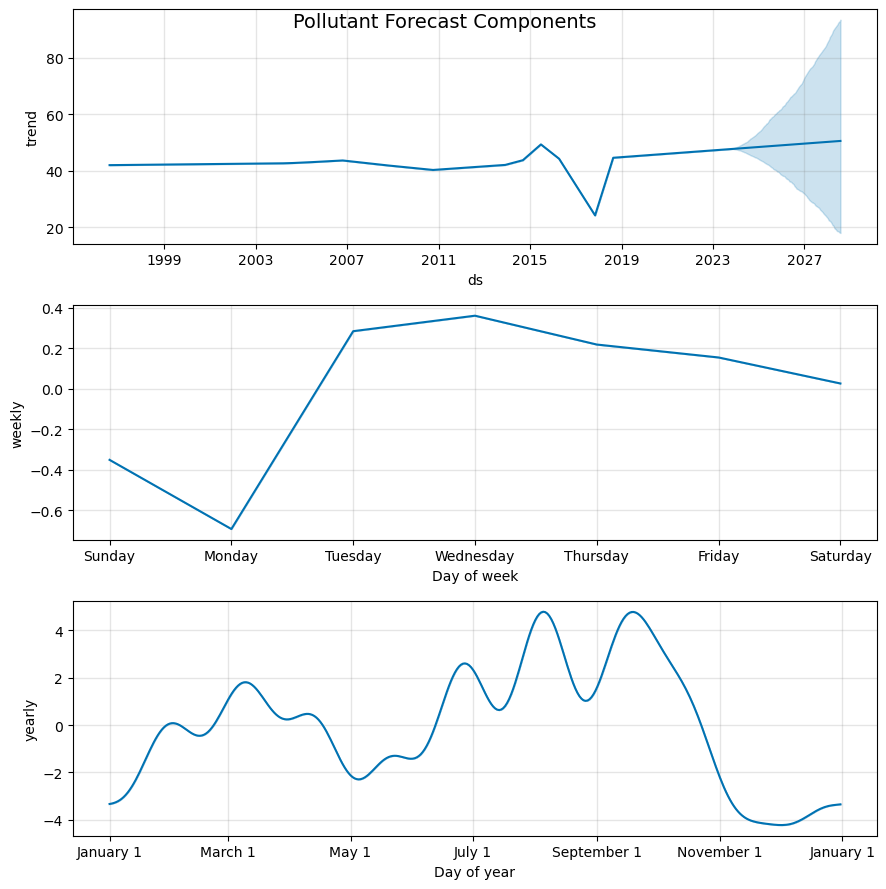

In [19]:
# Visualise the components of each forecast
fig3 = model_temperature.plot_components(forecast_temperature)
_ = fig3.suptitle('Temperature Forecast Components', fontsize=14)
fig4 = model_pollutant.plot_components(forecast_pollutant)
_ = fig4.suptitle('Pollutant Forecast Components', fontsize=14)

# Predicting births

We now want to forecast the number of births into the feature. We also want to use temperature and pollutant levels as regressors in the model. We will build a new Prophet model that includes these regressors.

```{tip}
Including additional regressors in the model allows us to account for external factors that might influence the trend and seasonality of the data. This can improve the accuracy of the forecast, especially if these factors have a significant impact on the target variable. In this case, we are including temperature and pollutant levels as regressors as an illustration of how to use this feature in Prophet, in practice these might not be the most relevant factors for predicting births.
```

In [20]:
df_births = data[['date', 'births']].rename(columns={'date': 'ds', 'births': 'y'})

# Add temperature and pollutant values to the dataframe
df_births['temperature'] = data['temperature']
df_births['pollutant_value'] = data['pollutant_value']

# Concatenate the forecasted temperature and pollutant values to the births dataframe
#df_births['temperature_forecast'] = forecast_temperature['yhat']
#df_births['pollutant_value_forecast'] = forecast_pollutant['yhat']

Prophet also allows us to include factors such as holidays in the model. We will include public holidays in Malaysia, which will allow the model to account for the impact of holidays on the number of births. We could also include other seasonalities or events that might affect the number of births, such as cultural or religious events. Notice also how we are including the temperature and pollutant levels as regressors in the model.

In [21]:
model_births = Prophet(changepoint_prior_scale=prior_scale)

# Add Malaysian holidays to the model
model_births.add_country_holidays(country_name='MY')

# Add a monthly seasonality to the model
model_births.add_seasonality(name='monthly', period=30.5, fourier_order=5)

# Add the temperature and pollutant value to the model as regressors
model_births.add_regressor('temperature')
model_births.add_regressor('pollutant_value')

# Fit the model
model_births.fit(df_births)

# Make a dataframe to hold future predictions
future_births = model_births.make_future_dataframe(periods=future_period)

# Add forecasted temperature and pollutant values to future_births
future_births['temperature'] = forecast_temperature['yhat'][-len(future_births):].reset_index(drop=True)
future_births['pollutant_value'] = forecast_pollutant['yhat'][-len(future_births):].reset_index(drop=True)

# Predict the future
forecast_births = model_births.predict(future_births)

08:35:12 - cmdstanpy - INFO - Chain [1] start processing
08:35:14 - cmdstanpy - INFO - Chain [1] done processing


Now that we have done the forecast, we can plot the forecasted values, as well as the uncertainty intervals, just as we did for temperature and pollutant levels.

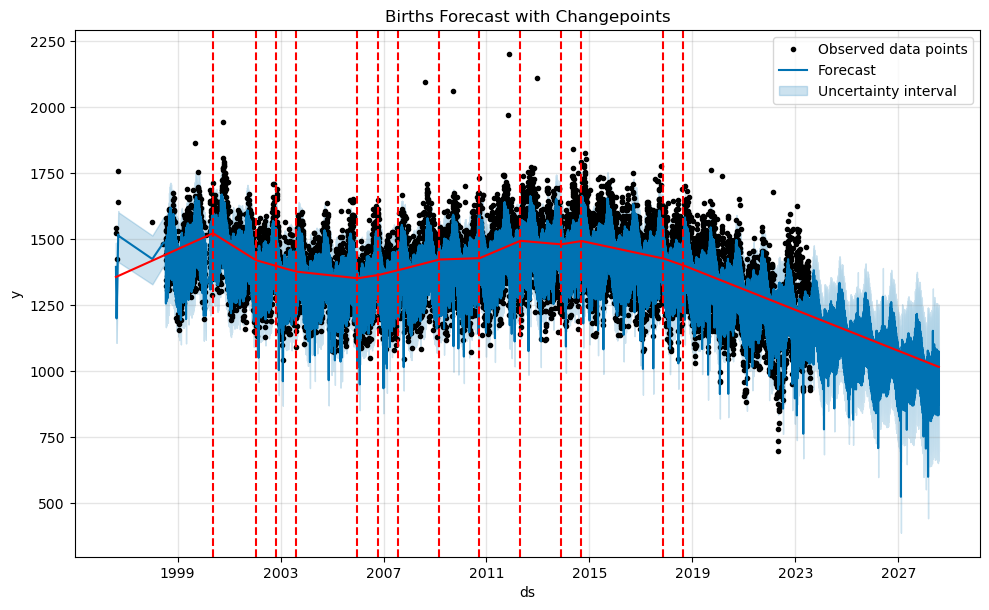

In [22]:
# Visualize the forecast
fig5 = model_births.plot(forecast_births, include_legend=True)
fig5.gca().set_title('Births Forecast with Changepoints')
# Add changepoints to the plot
a = add_changepoints_to_plot(fig5.gca(), model_births, forecast_births)

Let's also plot the components of the forecast, including the trend, seasonality, holidays, and the impact of the regressors. This will allow us to understand how these components contribute to the forecast and if and how the regressors influence the number of births.

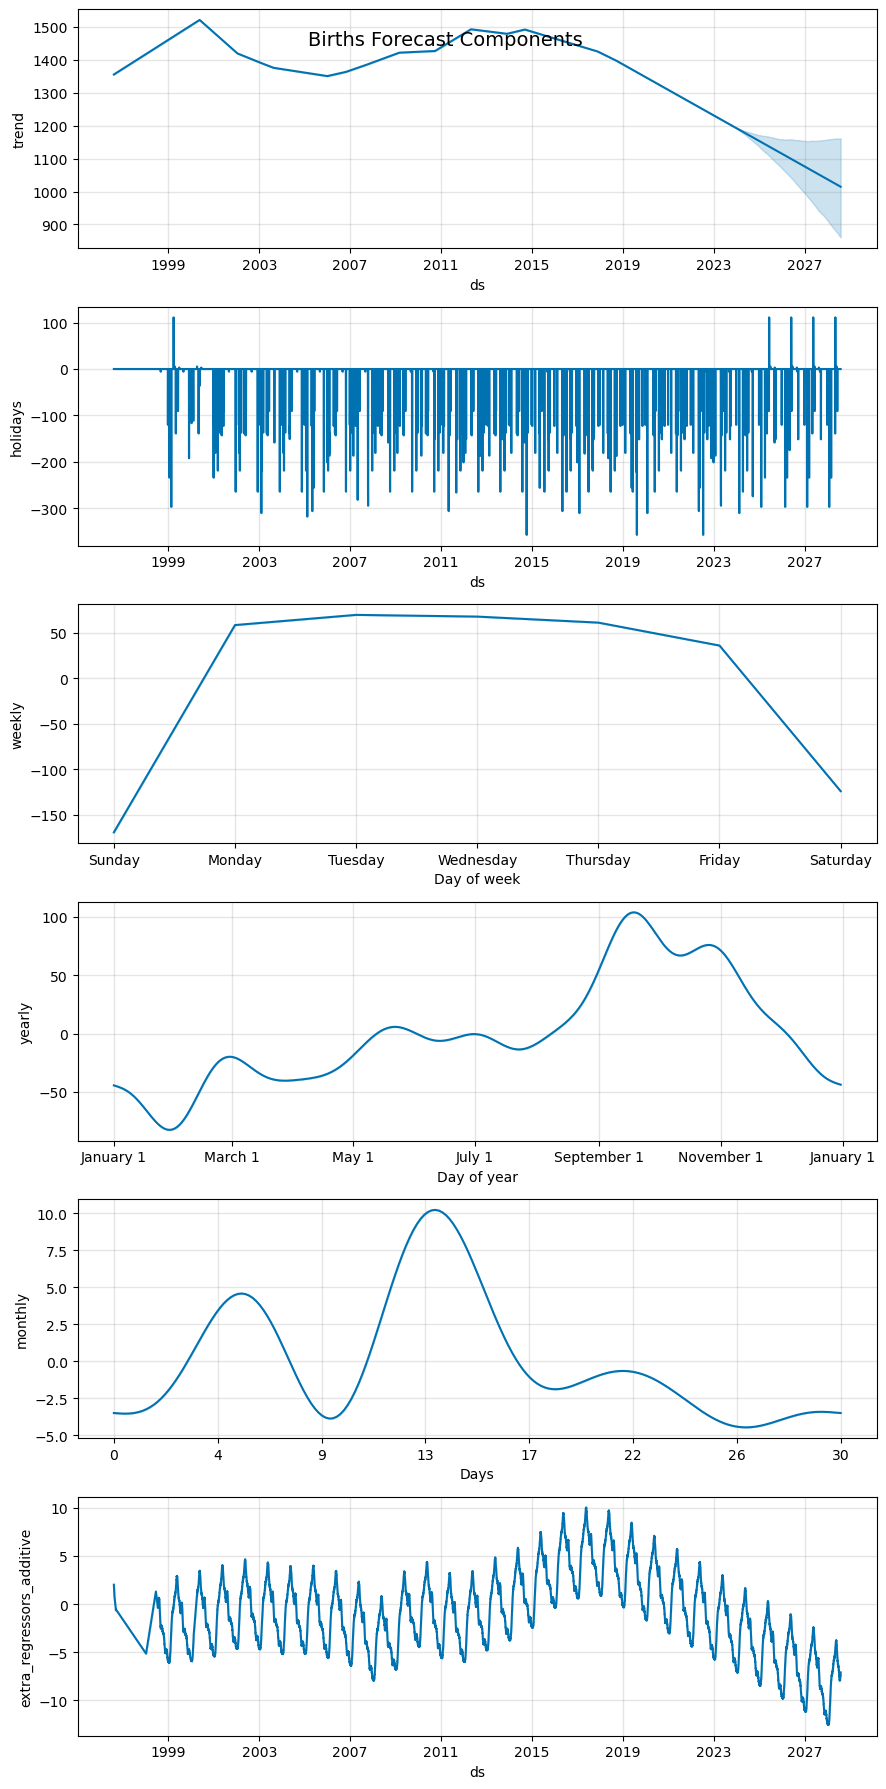

In [23]:
# Visualise the components of the forecast
fig6 = model_births.plot_components(forecast_births)
_ = fig6.suptitle('Births Forecast Components', fontsize=14)

Interestingly, there is a negative effect of many holidays on the number of births - this might be due to the fact that many births are planned, and people might avoid giving birth on holidays, or there might be other factors at play. We can also see that the number of births is highest between September and November.

## Cross validating the model

Prophet provides a convenient way to cross-validate the model using historical data. This allows us to evaluate the performance of the model on past data and tune the hyperparameters accordingly. We will use cross-validation to assess the forecast accuracy of the model and identify any potential issues. Cross validation in Prophet works on a rolling forecast origin, where the model is trained on historical data up to a certain point and then used to forecast future data. We can then compare the forecasted values with the actual values to evaluate the model's performance. The `initial` parameter specifies the size of the initial training period, and the `period` parameter specifies the size of the forecast `horizon`.

```{tip}
Cross validation produces a dataframe with `yhat`, `yhat_lower`, `yhat_upper` and `y` columns. The `yhat` column contains the forecasted values, the `yhat_lower` and `yhat_upper` columns contain the uncertainty intervals, and the `y` column contains the actual values. We can use this dataframe to calculate evaluation metrics such as mean absolute error (MAE), mean squared error (MSE), and root mean squared error (RMSE).
```

In [24]:
# Cross validate the model
from prophet.diagnostics import cross_validation

df_births_cv = cross_validation(model_births, initial='730 days', period='180 days', horizon = '365 days')
df_births_cv.head().style.background_gradient(cmap='Greens')

  0%|          | 0/49 [00:00<?, ?it/s]

08:35:16 - cmdstanpy - INFO - Chain [1] start processing
08:35:16 - cmdstanpy - INFO - Chain [1] done processing
08:35:16 - cmdstanpy - INFO - Chain [1] start processing
08:35:16 - cmdstanpy - INFO - Chain [1] done processing
08:35:16 - cmdstanpy - INFO - Chain [1] start processing
08:35:16 - cmdstanpy - INFO - Chain [1] done processing
08:35:16 - cmdstanpy - INFO - Chain [1] start processing
08:35:17 - cmdstanpy - INFO - Chain [1] done processing
08:35:17 - cmdstanpy - INFO - Chain [1] start processing
08:35:17 - cmdstanpy - INFO - Chain [1] done processing
08:35:17 - cmdstanpy - INFO - Chain [1] start processing
08:35:17 - cmdstanpy - INFO - Chain [1] done processing
08:35:17 - cmdstanpy - INFO - Chain [1] start processing
08:35:17 - cmdstanpy - INFO - Chain [1] done processing
08:35:18 - cmdstanpy - INFO - Chain [1] start processing
08:35:18 - cmdstanpy - INFO - Chain [1] done processing
08:35:18 - cmdstanpy - INFO - Chain [1] start processing
08:35:18 - cmdstanpy - INFO - Chain [1]

,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,1998-12-05 00:00:00,1311.555304,1259.649340,1367.864128,1349,1998-12-04 00:00:00
1,1998-12-06 00:00:00,1216.420565,1160.329819,1269.789724,1311,1998-12-04 00:00:00
2,1998-12-07 00:00:00,1373.392566,1319.401931,1428.821652,1399,1998-12-04 00:00:00
3,1998-12-08 00:00:00,1434.990681,1379.893977,1489.437516,1423,1998-12-04 00:00:00
4,1998-12-09 00:00:00,1449.400677,1393.617702,1506.548501,1420,1998-12-04 00:00:00


Prophet can also calculate performance metrics such as mean absolute error (MAE), mean squared error (MSE), and root mean squared error (RMSE) for the forecast. These metrics provide a quantitative measure of the model's accuracy and can help us evaluate the performance of the model. Let's look at the calculated metrics for the forecast.

We will be particularly interested in MAPE (Mean Absolute Percentage Error), which is a relative measure of the forecast accuracy. It is calculated as the average of the absolute percentage errors between the forecasted and actual values. A lower MAPE indicates a more accurate forecast. Here is the formula for MAPE:

$$MAPE = \frac{1}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right| \times 100$$

As an example, a MAPE of $\mathbf{0.046}$ would indicate that the forecast is $\mathbf{4.6\%}$ off from the actual value.

In [25]:
from prophet.diagnostics import performance_metrics

df_births_cv_p = performance_metrics(df_births_cv)
df_births_cv_p.head().style.background_gradient(cmap='Greens')

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,37 days 00:00:00,7044.649211,83.932409,64.313467,0.046796,0.037140,0.045922,0.682110
1,38 days 00:00:00,7065.587597,84.057050,64.387762,0.046818,0.036911,0.045946,0.680985
2,39 days 00:00:00,7081.623627,84.152383,64.466984,0.046857,0.037161,0.045984,0.680002
3,40 days 00:00:00,7159.995715,84.616758,64.878598,0.047116,0.037406,0.046254,0.676967
4,41 days 00:00:00,7172.213365,84.688921,65.028362,0.047190,0.037506,0.046333,0.672720


Let's plot the MAPE values for each forecast horizon to see how the forecast accuracy changes over time.

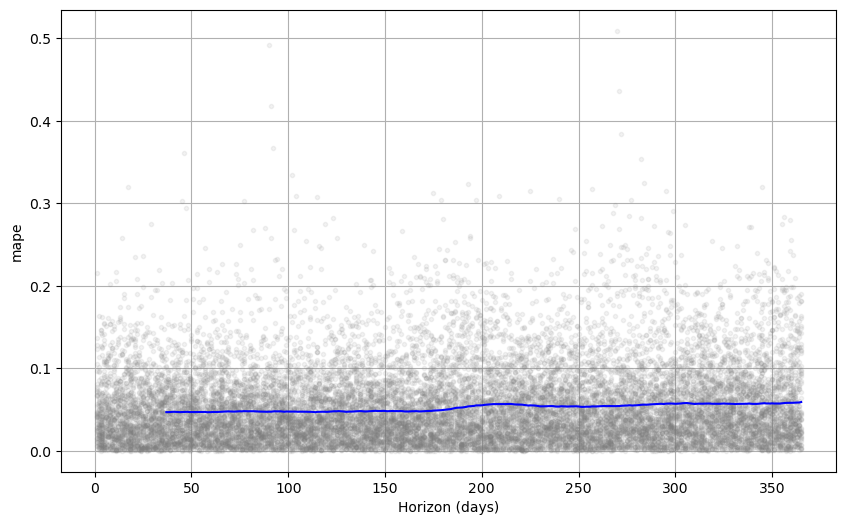

In [26]:
# Plot the MAPE performance metric
from prophet.plot import plot_cross_validation_metric

fig7 = plot_cross_validation_metric(df_births_cv, metric='mape')

Notice how the MAPE values stay relatively stable over time, around or just below 5%. This indicates that the model is performing well and providing accurate forecasts.

Let us now plot the output of the cross-validation, showing the actual values and forecasted values superimposed on each other. This will allow us to visually inspect the accuracy of the forecast over the period and horizon of the cross-validation.

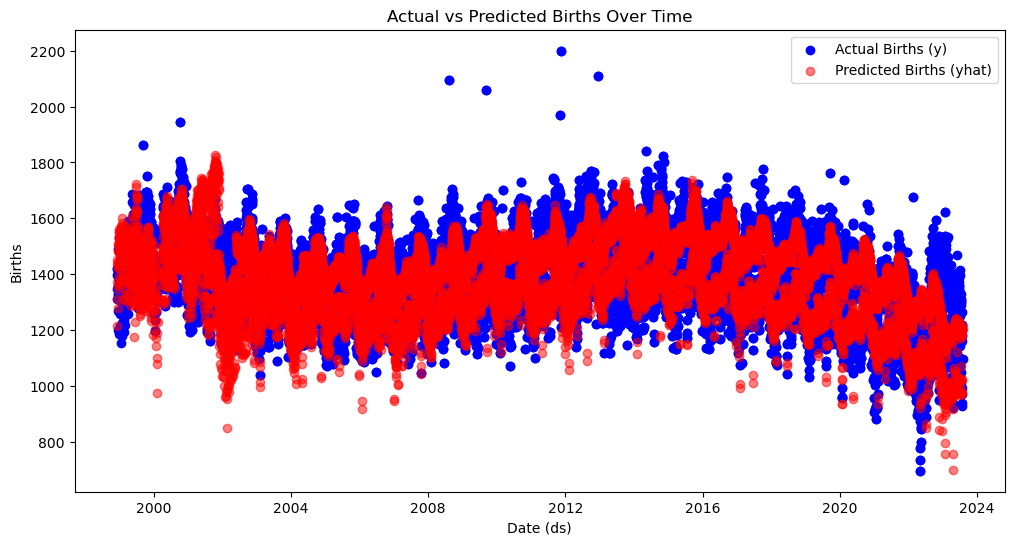

In [27]:
# Create a figure and axis
plt.figure(figsize=(12, 6))

# Plot actual values (y) as a scatter plot
plt.scatter(df_births_cv['ds'], df_births_cv['y'], color='blue', label='Actual Births (y)', alpha=1.0)

# Plot predicted values (yhat) as a scatter plot
plt.scatter(df_births_cv['ds'], df_births_cv['yhat'], color='red', label='Predicted Births (yhat)', alpha=0.5)

# Add labels and title
plt.xlabel('Date (ds)')
plt.ylabel('Births')
plt.title('Actual vs Predicted Births Over Time')
plt.legend()

# Show plot
plt.show()


# Final remarks

In this experiment, we used Prophet to forecast the number of births in Malaysia based on historical data. We also included temperature and pollutant levels as regressors in the model to account for external factors that might influence the trend and seasonality of the data. We used cross-validation to evaluate the forecast accuracy of the model and calculate performance metrics such as MAE, MSE, RMSE, and MAPE. The results show that the model is performing well and providing accurate forecasts.